# PASCAL VOC Efficient Segmentation Challenge


### Objective
The goal of this project is to design a computationally efficient deep learning model for semantic segmentation on the PASCAL VOC dataset while optimizing the Dice/FLOPS trade-off.

### Key Goals
- Achieve high segmentation accuracy
- Maintain low computational complexity
- Build a lightweight model suitable for efficient inference

#Libaries Installation and import

In [ ]:
!pip install -q kaggle gdown thop torchinfo torchview

In [ ]:
import os
import gc
import time
import random
import gdown

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from thop import profile
from torchinfo import summary
from torchview import draw_graph
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
#ImageNet normalisation constants (used throughout)
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

#Dataset

**Dataset Preparation**

The PASCAL VOC dataset contains 21 classes including background.
Images and segmentation masks are loaded and processed using a custom PyTorch Dataset class.

Basic preprocessing steps include:
- resizing images
- normalization
- optional data augmentation

**Downloading Dataset**

In [ ]:
# Download Kaggle credentials
import gdown
gdown.download(
    f"https://drive.google.com/uc?id=1pz-L_l9rZ28elawg3gXOj0a7V0nQPddu",
    "kaggle.json",
    quiet=False,
)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Remove the broken, incomplete tar file if it exists from the previous run
!rm -f VOCtrainval_11-May-2012.tar

# Download and extract PASCAL VOC 2012
# (Added -c to resume if disconnected, and --show-progress to track it)
!wget -c --show-progress http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar

# Extract the archive
!tar -xf VOCtrainval_11-May-2012.tar

Downloading...
From: https://drive.google.com/uc?id=1pz-L_l9rZ28elawg3gXOj0a7V0nQPddu
To: /content/kaggle.json
100%|██████████| 65.0/65.0 [00:00<00:00, 158kB/s]


--2026-03-17 16:06:46--  http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.50
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.50|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar [following]
--2026-03-17 16:06:46--  https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar [following]
--2026-03-17 16:06:47--  https://thor.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
Resolving thor.robots.ox.ac.uk (thor.ro

**Dataset paths & basic statistics**

In [ ]:
ROOT_DIR  = "/content/VOCdevkit/VOC2012"
IMG_DIR   = os.path.join(ROOT_DIR, "JPEGImages")
MASK_DIR  = os.path.join(ROOT_DIR, "SegmentationClass")
IMG_SIZE  = 300

with open(os.path.join(ROOT_DIR, "ImageSets/Segmentation/train.txt")) as f:
    train_ids = f.read().splitlines()

print(f"Segmentation training images: {len(train_ids)}")

Segmentation training images: 1464


**Visualise sample images & masks**

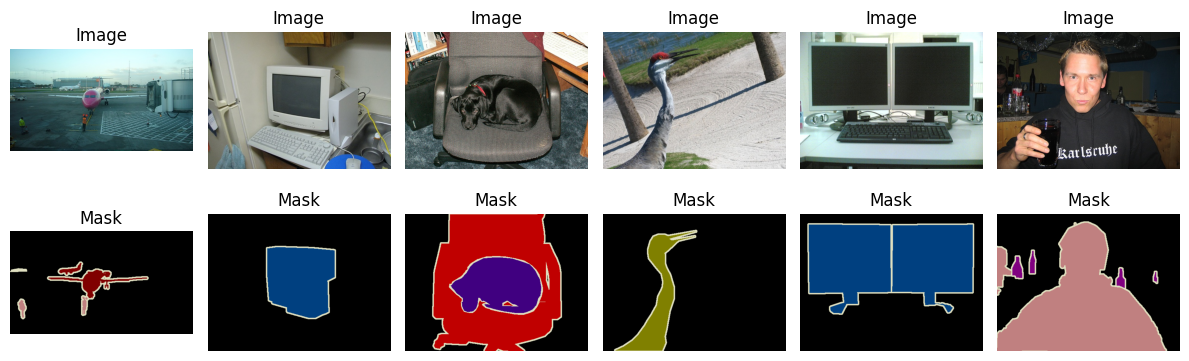

In [ ]:
def show_samples(image_ids, img_dir, mask_dir, num_samples=6):
    plt.figure(figsize=(12, 4))
    for i, img_id in enumerate(image_ids[:num_samples]):
        img  = Image.open(os.path.join(img_dir,  img_id + ".jpg")).convert("RGB")
        mask = Image.open(os.path.join(mask_dir, img_id + ".png"))

        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img);  plt.title("Image"); plt.axis("off")

        plt.subplot(2, num_samples, num_samples + i + 1)
        plt.imshow(mask); plt.title("Mask");  plt.axis("off")
    plt.tight_layout(); plt.show()

show_samples(train_ids, IMG_DIR, MASK_DIR)

**Load images & masks**

In [ ]:
def load_data_voc(image_ids, img_dir, mask_dir, size=IMG_SIZE):
    """Load VOC images and masks, resize to `size × size`."""
    imgs, masks = [], []
    for img_id in image_ids:
        try:
            img  = Image.open(os.path.join(img_dir,  img_id + ".jpg")).convert("RGB")
            mask = Image.open(os.path.join(mask_dir, img_id + ".png"))
        except FileNotFoundError:
            continue
        imgs.append(np.array(img.resize((size, size), Image.BILINEAR)))
        masks.append(np.array(mask.resize((size, size), Image.NEAREST)))
    return np.array(imgs), np.array(masks)

gc.collect()

images, masks = load_data_voc(train_ids, IMG_DIR, MASK_DIR)
print("Images:", images.shape, " Masks:", masks.shape)

Images: (1464, 300, 300, 3)  Masks: (1464, 300, 300)


#Data spliting n Preprocessing

**Train-validation split  and  held-out test set**

Dataset split
Train: (1171, 300, 300, 3)
Val:   (293, 300, 300, 3)
Test:  (1449, 300, 300, 3)

Image statistics
dtype: uint8
range: 0 – 255


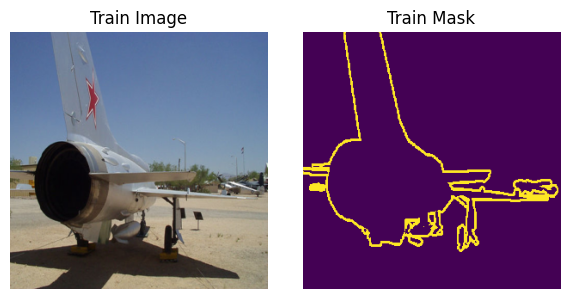

In [ ]:
from sklearn.model_selection import train_test_split

# Split VOC TRAIN set into 80/20
X_train, X_val, y_train, y_val = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

# Load official VOC validation set → TEST
with open(os.path.join(ROOT_DIR, "ImageSets/Segmentation/val.txt")) as f:
    test_ids = f.read().splitlines()

X_test, y_test = load_data_voc(test_ids, IMG_DIR, MASK_DIR)

print("Dataset split")
print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

print("\nImage statistics")
print(f"dtype: {X_train.dtype}")
print(f"range: {X_train.min()} – {X_train.max()}")

# sanity visualization
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(X_train[0])
plt.title("Train Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(y_train[0])
plt.title("Train Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

#Model

**Model Architecture**

We use a lightweight encoder–decoder architecture designed for efficient semantic segmentation.

Design considerations:
- low FLOPS
- minimal parameters
- good spatial feature preservation

**Model Building**

In [ ]:
class VOCModel(nn.Module):
    def __init__(self, num_classes=21):
        super(VOCModel, self).__init__()

        # STAGE 1: Extracts low-level spatial features (1/8 resolution)
        self.backbone_stage1 = nn.Sequential(
            Conv2dNormActivation(3, 16, kernel_size=3, stride=2, padding=1),
            InvertedResidual(16, 16, stride=1, expand_ratio=1),
            InvertedResidual(16, 24, stride=2, expand_ratio=4),
            InvertedResidual(24, 24, stride=1, expand_ratio=3),
            InvertedResidual(24, 40, stride=2, expand_ratio=3),
            InvertedResidual(40, 40, stride=1, expand_ratio=3),
        )

        # STAGE 2: Extracts high-level semantic features (1/16 resolution)
        self.backbone_stage2 = nn.Sequential(
            InvertedResidual(40, 80, stride=2, expand_ratio=4), # Strided downsampling
            InvertedResidual(80, 80, stride=1, expand_ratio=3),
        )

        # --- Lightweight Decoder / Feature Fusion ---

        # Projects 80 channels down to 128 cheaply
        self.high_level_conv = nn.Sequential(
            nn.Conv2d(80, 128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        # Projects 40 channels up to 128 cheaply
        self.low_level_conv = nn.Sequential(
            nn.Conv2d(40, 128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        # Depthwise Separable Classifier (operates on the fused features)
        self.classifier = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1, groups=128, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, num_classes, kernel_size=1)
        )

    def forward(self, x):
        input_shape = x.shape[-2:]

        # 1. Extract features at two different scales
        low_features = self.backbone_stage1(x)         # High spatial detail
        high_features = self.backbone_stage2(low_features) # High semantic meaning

        # 2. Process and upsample high-level features by 2x
        high_proj = self.high_level_conv(high_features)
        high_upsampled = F.interpolate(high_proj, size=low_features.shape[-2:], mode='bilinear', align_corners=False)

        # 3. Process low-level features
        low_proj = self.low_level_conv(low_features)

        # 4. Fuse (The Skip Connection)
        fused = high_upsampled + low_proj

        # 5. Apply classifier to the fused features
        out = self.classifier(fused)

        # 6. Final upsample to original image size
        out = F.interpolate(out, size=input_shape, mode='bilinear', align_corners=False)

        return out

**Model summary & architecture graph**

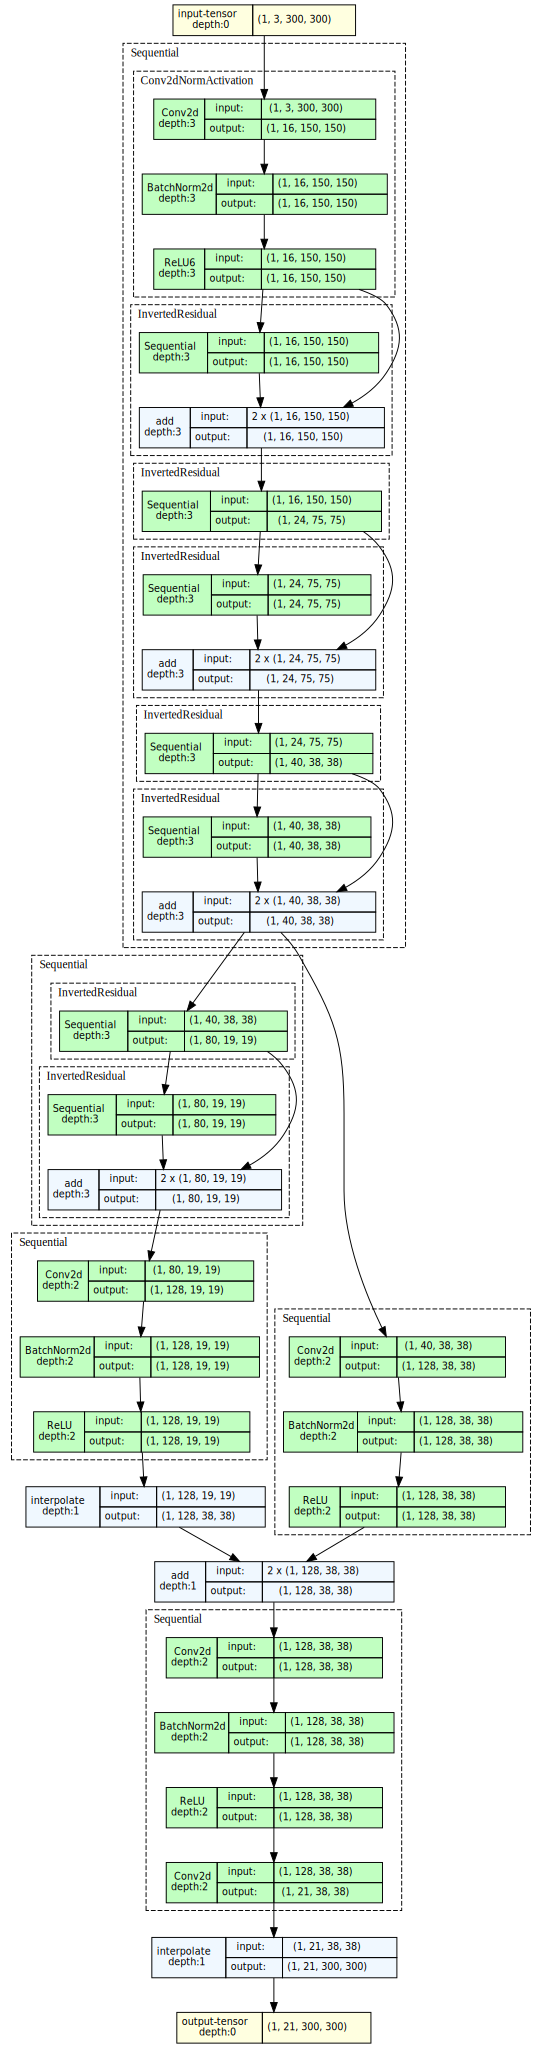

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# Missing definitions for model architecture
# These are commonly found in architectures like MobileNetV2
class Conv2dNormActivation(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, groups=1, dilation=1,
                 bias=False, activation_layer=nn.ReLU6):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, dilation, groups, bias),
            nn.BatchNorm2d(out_channels),
            activation_layer(inplace=True) if activation_layer is not None else nn.Identity()
        )

class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio):
        super(InvertedResidual, self).__init__()
        self.stride = stride
        hidden_dim = int(round(inp * expand_ratio))
        self.use_res_connect = self.stride == 1 and inp == oup

        layers = []
        if expand_ratio != 1:
            # pw
            layers.append(Conv2dNormActivation(inp, hidden_dim, kernel_size=1, activation_layer=nn.ReLU6))
        layers.extend([
            # dw
            Conv2dNormActivation(hidden_dim, hidden_dim, kernel_size=3, stride=stride, padding=1, groups=hidden_dim, activation_layer=nn.ReLU6),
            # pw-linear
            nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
            nn.BatchNorm2d(oup),
        ])
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

# Model architecture - duplicated from cell GKWpT3lDhBIl to make this cell runnable
# This duplication is necessary because the prompt dictates that the fix must be applied *within* the selected cell (Vrh_NxDcO48O)
# and the VOCModel definition relies on the classes defined above.
class VOCModel(nn.Module):
    def __init__(self, num_classes=21):
        super(VOCModel, self).__init__()

        # STAGE 1: Extracts low-level spatial features (1/8 resolution)
        self.backbone_stage1 = nn.Sequential(
            Conv2dNormActivation(3, 16, kernel_size=3, stride=2, padding=1),
            InvertedResidual(16, 16, stride=1, expand_ratio=1),
            InvertedResidual(16, 24, stride=2, expand_ratio=4),
            InvertedResidual(24, 24, stride=1, expand_ratio=3),
            InvertedResidual(24, 40, stride=2, expand_ratio=3),
            InvertedResidual(40, 40, stride=1, expand_ratio=3),
        )

        # STAGE 2: Extracts high-level semantic features (1/16 resolution)
        self.backbone_stage2 = nn.Sequential(
            InvertedResidual(40, 80, stride=2, expand_ratio=4), # Strided downsampling
            InvertedResidual(80, 80, stride=1, expand_ratio=3),
        )

        # --- Lightweight Decoder / Feature Fusion ---

        # Projects 80 channels down to 128 cheaply
        self.high_level_conv = nn.Sequential(
            nn.Conv2d(80, 128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        # Projects 40 channels up to 128 cheaply
        self.low_level_conv = nn.Sequential(
            nn.Conv2d(40, 128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        # Depthwise Separable Classifier (operates on the fused features)
        self.classifier = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1, groups=128, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, num_classes, kernel_size=1)
        )

    def forward(self, x):
        input_shape = x.shape[-2:]

        # 1. Extract features at two different scales
        low_features = self.backbone_stage1(x)         # High spatial detail
        high_features = self.backbone_stage2(low_features) # High semantic meaning

        # 2. Process and upsample high-level features by 2x
        high_proj = self.high_level_conv(high_features)
        high_upsampled = F.interpolate(high_proj, size=low_features.shape[-2:], mode='bilinear', align_corners=False)

        # 3. Process low-level features
        low_proj = self.low_level_conv(low_features)

        # 4. Fuse (The Skip Connection)
        fused = high_upsampled + low_proj

        # 5. Apply classifier to the fused features
        out = self.classifier(fused)

        # 6. Final upsample to original image size
        out = F.interpolate(out, size=input_shape, mode='bilinear', align_corners=False)

        return out

# create model
model = VOCModel(num_classes=21)

# model summary
summary(model, input_size=(1, 3, 300, 300))

# architecture graph
graph = draw_graph(model, input_size=(1, 3, 300, 300), expand_nested=True)
graph.visual_graph

**Loss functions**

In [ ]:
class DiceCELoss(nn.Module):
    def __init__(self):
        super(DiceCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1e-6):
        # Cross Entropy Part
        ce_loss = F.cross_entropy(inputs, targets, reduction='mean', ignore_index=255)

        # Dice Part
        inputs_soft = F.softmax(inputs, dim=1)
        num_classes = inputs.size(1)

        # Create a mask for valid pixels (not ignore_index) and add channel dim natively
        valid_mask = (targets != 255).unsqueeze(1).float()

        # Apply the mask to inputs_soft and targets_one_hot
        targets_one_hot = F.one_hot(targets.clamp(0, num_classes - 1), num_classes).permute(0, 3, 1, 2).float()
        targets_one_hot = targets_one_hot * valid_mask
        inputs_soft = inputs_soft * valid_mask

        # IMPROVEMENT 1: Calculate over the whole batch (dim=0, 2, 3) instead of per-image
        intersection = (inputs_soft * targets_one_hot).sum(dim=(0, 2, 3))

        # IMPROVEMENT 2: Square the network predictions in the denominator
        union = (inputs_soft ** 2).sum(dim=(0, 2, 3)) + targets_one_hot.sum(dim=(0, 2, 3))

        dice_score = (2. * intersection + smooth) / (union + smooth)
        dice_loss = 1. - dice_score.mean()

        # IMPROVEMENT 3: Weighted combination (often CE loss easily overpowers Dice in early epochs)
        return ce_loss + dice_loss

#Data Augmentation

In [ ]:
class VOCSegDataset(Dataset):
    """
    Dataset wrapper for PASCAL VOC segmentation.
    Includes augmentations for robustness to noise, blur, compression, and lighting changes.
    """

    def __init__(self, images, masks, num_classes=21, augment=False):
        self.images = images
        self.masks = masks
        self.num_classes = num_classes
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = self.images[idx].copy().astype(np.float32)
        mask  = self.masks[idx].copy()

        if self.augment:

            if random.random() < 0.5:
                image = np.fliplr(image).copy()
                mask  = np.fliplr(mask).copy()

            if random.random() < 0.5:

                scale = random.uniform(0.85, 1.15)

                h, w = image.shape[:2]
                nh, nw = int(h*scale), int(w*scale)

                image = np.array(
                    Image.fromarray(image.astype(np.uint8)).resize(
                        (nw, nh), Image.BILINEAR)
                ).astype(np.float32)

                mask = np.array(
                    Image.fromarray(mask).resize(
                        (nw, nh), Image.NEAREST)
                )

                top  = max((nh - 300)//2, 0)
                left = max((nw - 300)//2, 0)

                image = image[top:top+300, left:left+300]
                mask  = mask[top:top+300, left:left+300]

                if image.shape[0] != 300 or image.shape[1] != 300:

                    image = np.array(
                        Image.fromarray(image.astype(np.uint8)).resize(
                            (300,300), Image.BILINEAR)
                    ).astype(np.float32)

                    mask = np.array(
                        Image.fromarray(mask).resize(
                            (300,300), Image.NEAREST)
                    )

            if random.random() < 0.5:
                alpha = random.uniform(0.85,1.15)
                beta  = random.uniform(-15,15)
                image = np.clip(alpha*image + beta, 0, 255)

            if random.random() < 0.4:
                noise = np.random.normal(0,4,image.shape)
                image = np.clip(image + noise,0,255)

            if random.random() < 0.3:
                from PIL import ImageFilter
                pil = Image.fromarray(image.astype(np.uint8))
                image = np.array(
                    pil.filter(
                        ImageFilter.GaussianBlur(
                            radius=random.uniform(0.4,1.2)
                        )
                    )
                ).astype(np.float32)

            if random.random() < 0.3:
                sp = np.random.rand(image.shape[0], image.shape[1])
                image[sp < 0.01] = 0
                image[sp > 0.99] = 255

            if random.random() < 0.3:
                import io
                pil = Image.fromarray(image.astype(np.uint8))
                buffer = io.BytesIO()
                pil.save(buffer, format="JPEG", quality=random.randint(35,75))
                buffer.seek(0)
                image = np.array(Image.open(buffer).convert("RGB")).astype(np.float32)

        image = (image / 255.0 - MEAN) / STD
        image = torch.tensor(image, dtype=torch.float32).permute(2,0,1).contiguous()

        mask = np.where(
            (mask >= 0) & (mask < self.num_classes),
            mask,
            255
        )

        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask


train_dataset = VOCSegDataset(X_train, y_train, augment=True)
val_dataset   = VOCSegDataset(X_val,   y_val,   augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

#Model Training

**Training Strategy**

The model is trained using a combination of Cross Entropy Loss and Dice Loss.

Optimization techniques used:
- AdamW optimizer
- cosine learning rate scheduling
- mixed precision training

In [ ]:
def pixel_accuracy(outputs, masks, ignore_index=255):
    """Fraction of correctly predicted valid pixels."""

    preds = torch.argmax(outputs, dim=1)
    valid = masks != ignore_index

    correct = (preds[valid] == masks[valid]).float().sum()
    total   = valid.float().sum()

    return correct / (total + 1e-6)


class EarlyStopping:
    """
    Stop training when validation Dice stops improving.
    Using Dice instead of loss aligns with competition metric.
    """

    def __init__(self, patience=10):

        self.patience = patience
        self.counter = 0
        self.best_dice = 0
        self.stop = False

    def __call__(self, val_dice):

        if val_dice > self.best_dice:
            self.best_dice = val_dice
            self.counter = 0
        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.stop = True


class ModelCheckpoint:
    """
    Save model when validation Dice improves.
    """

    def __init__(self, filepath="MobileUNet_best.pth"):

        self.filepath = filepath
        self.best_val_loss = float('inf')


    def __call__(self, model, val_loss):

        if val_loss < self.best_val_loss:

            self.best_val_loss = val_loss
            torch.save(model.state_dict(), self.filepath)

            print(f"  ✓ Best model saved (Dice = {val_loss:.4f})")

In [ ]:
from torch.cuda.amp import autocast, GradScaler

def train_model(model, train_loader, val_loader,
                optimizer, scheduler,
                early_stopping, model_checkpoint,
                device, epochs=40):

    """
    Training loop with CE + Dice loss, mixed precision,
    gradient clipping, and validation Dice monitoring.
    """

    class_weights = torch.ones(21, device=device)
    class_weights[0] = 0.3

    ce_loss = nn.CrossEntropyLoss(
        weight=class_weights,
        ignore_index=255,
        label_smoothing=0.05
    )

    dice_loss = DiceCELoss()
    # Assuming macro_dice_score is defined elsewhere and is accessible
    # If not, it needs to be defined or imported here.
    # For this fix, we assume macro_dice_score is available.

    scaler = GradScaler()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "val_dice": []
    }

    for epoch in range(epochs):


        # Training
        model.train()

        t_loss = 0.0
        t_acc = 0.0

        for imgs, msks in train_loader:

            imgs = imgs.to(device)
            msks = msks.to(device).long()

            optimizer.zero_grad(set_to_none=True)

            with autocast():

                outputs = model(imgs)

                # slightly stronger Dice weight
                loss = 0.7 * dice_loss(outputs, msks) + 0.3 * ce_loss(outputs, msks)

            scaler.scale(loss).backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()

            t_loss += loss.item()
            t_acc  += pixel_accuracy(outputs, msks).item()

        t_loss /= len(train_loader)
        t_acc  /= len(train_loader)


        # Validation

        model.eval()

        v_loss = 0.0
        v_acc = 0.0
        v_dice_score_epoch = 0.0 # Initialize variable for validation dice score

        with torch.no_grad():

            for imgs, msks in val_loader:

                imgs = imgs.to(device)
                msks = msks.to(device).long()

                with autocast():
                    outputs = model(imgs)
                    loss = 0.7 * dice_loss(outputs, msks) + 0.3 * ce_loss(outputs, msks)

                # Calculate Dice score for validation
                v_dice_score_epoch += macro_dice_score(outputs, msks).item()

                v_loss += loss.item()
                v_acc  += pixel_accuracy(outputs, msks).item()

        v_dice_score_epoch /= len(val_loader)
        v_loss /= len(val_loader)
        v_acc  /= len(val_loader)

        # scheduler after validation (more stable)
        scheduler.step()

        print(
            f"Epoch {epoch+1}/{epochs}  "
            f"loss: {t_loss:.4f}  acc: {t_acc:.4f}  "
            f"val_loss: {v_loss:.4f}  val_acc: {v_acc:.4f}  "
            f"val_dice: {v_dice_score_epoch:.4f}  " # Add val_dice to print
            f"lr: {optimizer.param_groups[0]['lr']:.2e}"
        )

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        history["val_dice"].append(v_dice_score_epoch) # Append val_dice to history

        model_checkpoint(model, v_dice_score_epoch)
        early_stopping(v_dice_score_epoch) # Use val_dice for early stopping as well

        if early_stopping.stop:
            print("Early stopping triggered.")
            break

    return history

**Initialise model, optimiser & train**

In [ ]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

torch.backends.cudnn.benchmark = True   # faster convolution selection
torch.cuda.empty_cache()


print("Unique mask values — train:", np.unique(y_train))
print("Unique mask values — val  :", np.unique(y_val))


# Model

model = VOCModel(num_classes=21).to(device)



# Optimizer

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)



# Learning rate scheduler

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,     # restart every 10 epochs
    T_mult=2,
    eta_min=1e-6
)


# Early stopping
early_stopping = EarlyStopping(patience=40)


# Model checkpoint
model_checkpoint = ModelCheckpoint("MobileUNet_best.pth")


# Train
history = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    early_stopping,
    model_checkpoint,
    device,
    epochs=40
)

Unique mask values — train: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20 255]
Unique mask values — val  : [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20 255]


/tmp/ipykernel_1728/540832190.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_1728/540832190.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1728/540832190.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/40  loss: 2.9064  acc: 0.5987  val_loss: 2.3159  val_acc: 0.7323  val_dice: 0.5054  lr: 2.93e-04
  ✓ Best model saved (Dice = 0.5054)
Epoch 2/40  loss: 2.3014  acc: 0.7267  val_loss: 2.2492  val_acc: 0.7329  val_dice: 0.5709  lr: 2.71e-04
Epoch 3/40  loss: 2.2652  acc: 0.7251  val_loss: 2.1892  val_acc: 0.7322  val_dice: 0.4891  lr: 2.38e-04
  ✓ Best model saved (Dice = 0.4891)
Epoch 4/40  loss: 2.2205  acc: 0.7285  val_loss: 2.1594  val_acc: 0.7355  val_dice: 0.4842  lr: 1.97e-04
  ✓ Best model saved (Dice = 0.4842)
Epoch 5/40  loss: 2.1965  acc: 0.7288  val_loss: 2.1476  val_acc: 0.7351  val_dice: 0.4748  lr: 1.50e-04
  ✓ Best model saved (Dice = 0.4748)
Epoch 6/40  loss: 2.1845  acc: 0.7280  val_loss: 2.1340  val_acc: 0.7358  val_dice: 0.4789  lr: 1.04e-04
Epoch 7/40  loss: 2.1778  acc: 0.7288  val_loss: 2.1275  val_acc: 0.7365  val_dice: 0.4698  lr: 6.26e-05
  ✓ Best model saved (Dice = 0.4698)
Epoch 8/40  loss: 2.1649  acc: 0.7294  val_loss: 2.1226  val_acc: 0.7351  val_di

In [ ]:
# Load best trained model

model = VOCModel(num_classes=21).to(device)

model.load_state_dict(
    torch.load("MobileUNet_best.pth", map_location=device)
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


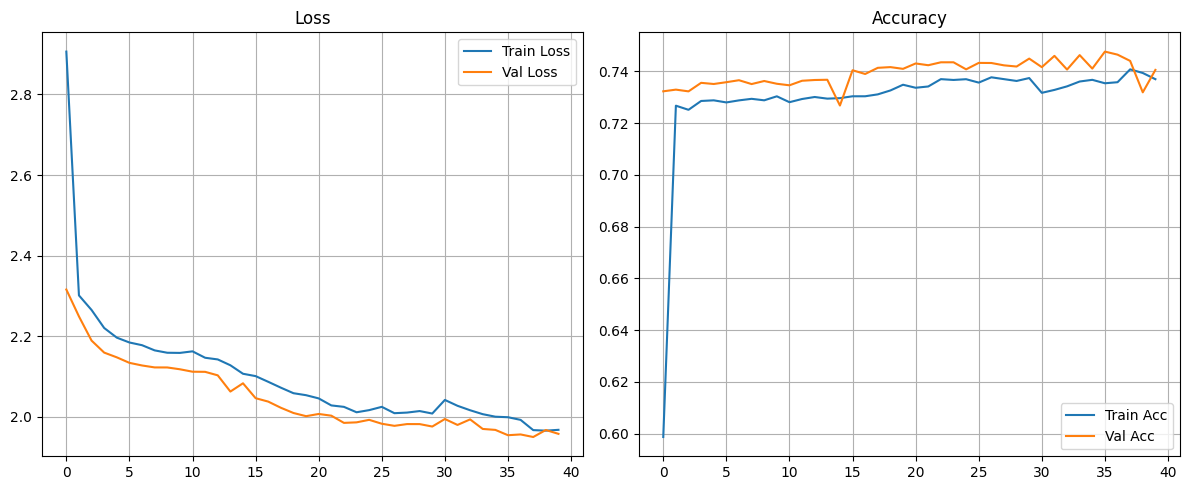

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid()

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"],   label="Val Acc")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid()

plt.tight_layout(); plt.show()

# **Inference**

In [ ]:
def run_inference(in_dir, out_dir, model, device):
    os.makedirs(out_dir, exist_ok=True)
    model.eval()

    image_files = [f for f in os.listdir(in_dir) if f.endswith(('.jpg', '.png'))]
    print(f"Found {len(image_files)} images. Running inference...")

    with torch.no_grad():
        for filename in tqdm(image_files):
            img_path = os.path.join(in_dir, filename)
            img = Image.open(img_path).convert("RGB")
            original_size = img.size # (W, H)

            # Prepare input (3, 300, 300)
            input_img = img.resize((300, 300))
            input_tensor = np.array(input_img).astype(np.float32) / 255.0
            input_tensor = (input_tensor - MEAN) / STD
            input_tensor = torch.from_numpy(input_tensor).permute(2, 0, 1).unsqueeze(0).to(device)

            # Forward pass
            output = model(input_tensor)

            # End-to-end mapping: argmax to get pixel-wise integer mask [0, 20]
            pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

            # Save results (ensure integer format)
            mask_img = Image.fromarray(pred_mask.astype(np.uint8))
            # Resize back to original if required, otherwise stay at 300x300
            mask_img.save(os.path.join(out_dir, filename.replace(".jpg", ".png")))

In [ ]:
def predict_single_image(image, model, device, use_tta=True):
    """
    Run inference on a single image.

    Parameters
    ----------
    image : numpy array (H,W,3) uint8
    model : trained model
    device : torch device
    use_tta : if True, uses horizontal flip TTA

    Returns
    -------
    pred : (H,W) numpy array of class indices (0–20)
    binary_mask : (H,W) uint8 binary mask (0 background, 255 foreground)
    elapsed : inference time in seconds
    """

    model.eval()

    # Normalize image
    img = image.astype(np.float32) / 255.0
    img = (img - MEAN) / STD

    tensor = torch.from_numpy(img).permute(2,0,1).unsqueeze(0).to(device).float()

    start = time.time()

    with torch.no_grad():

        with torch.cuda.amp.autocast():

            if use_tta:

                # original prediction
                out1 = model(tensor)

                # flipped prediction
                flipped = torch.flip(tensor, dims=[3])
                out2 = model(flipped)
                out2 = torch.flip(out2, dims=[3])

                output = (out1 + out2) / 2

            else:
                output = model(tensor)

        # safety resize (sometimes models output slightly different size)
        if output.shape[-1] != 300:
            output = F.interpolate(
                output,
                size=(300,300),
                mode="bilinear",
                align_corners=False
            )

        pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    elapsed = time.time() - start

    # Convert multi-class → binary mask
    binary_mask = (pred > 0).astype(np.uint8) * 255

    return pred, binary_mask, elapsed

def visualize_segmentation(image, predicted_mask, ground_truth_mask):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, data, title in zip(
        axes,
        [image.astype(np.uint8), predicted_mask, ground_truth_mask],
        ["Original Image", "Predicted Mask", "Ground Truth Mask"],
    ):
        kw = {} if title == "Original Image" else {"cmap": "jet"}
        ax.imshow(data, **kw); ax.set_title(title); ax.axis("off")
    plt.tight_layout(); plt.show()

def visualize_segmentation_with_overlay(image, predicted_mask, ground_truth_mask):

    overlay = image.copy().astype(np.uint8)

    # highlight predicted objects
    overlay[predicted_mask > 0] = [255,0,0]

    fig, axes = plt.subplots(1,4,figsize=(16,4))

    axes[0].imshow(image.astype(np.uint8))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(predicted_mask, cmap="jet")
    axes[1].set_title("Predicted Mask")
    axes[1].axis("off")

    axes[2].imshow(ground_truth_mask, cmap="jet")
    axes[2].set_title("Ground Truth Mask")
    axes[2].axis("off")

    axes[3].imshow(overlay)
    axes[3].set_title("Overlay")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1728/1030540114.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Sample 0 — inference time: 4.0381s


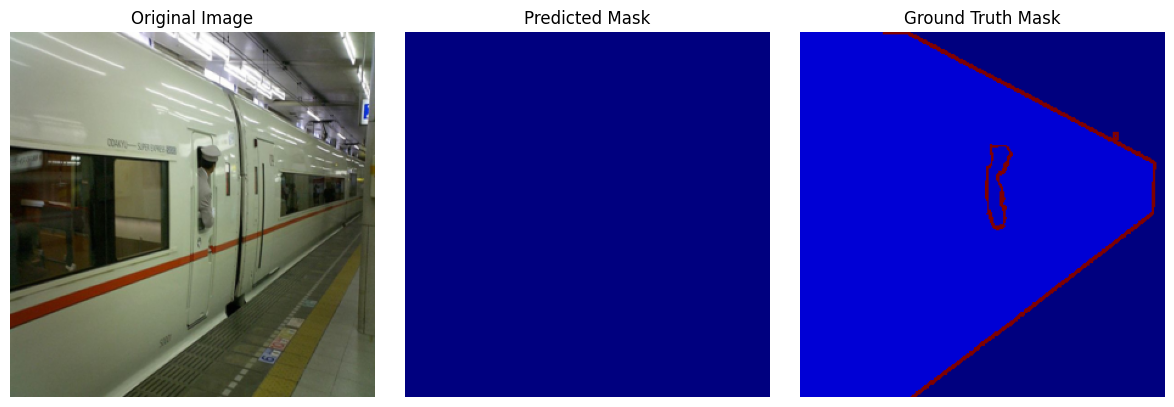

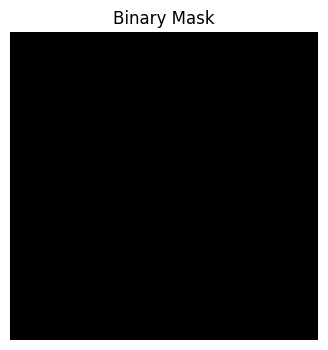

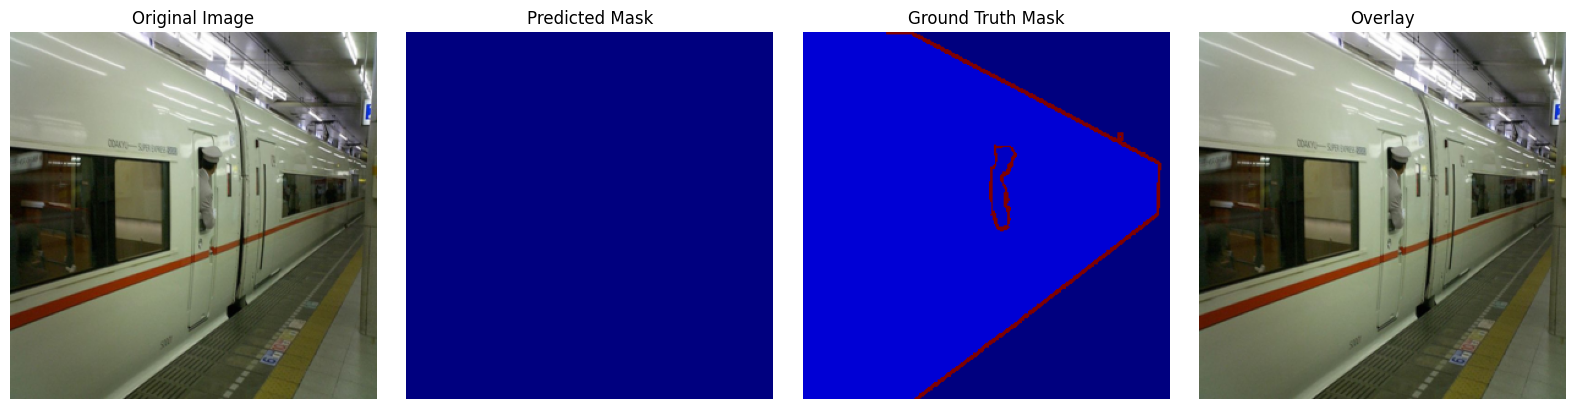

Sample 10 — inference time: 0.0104s


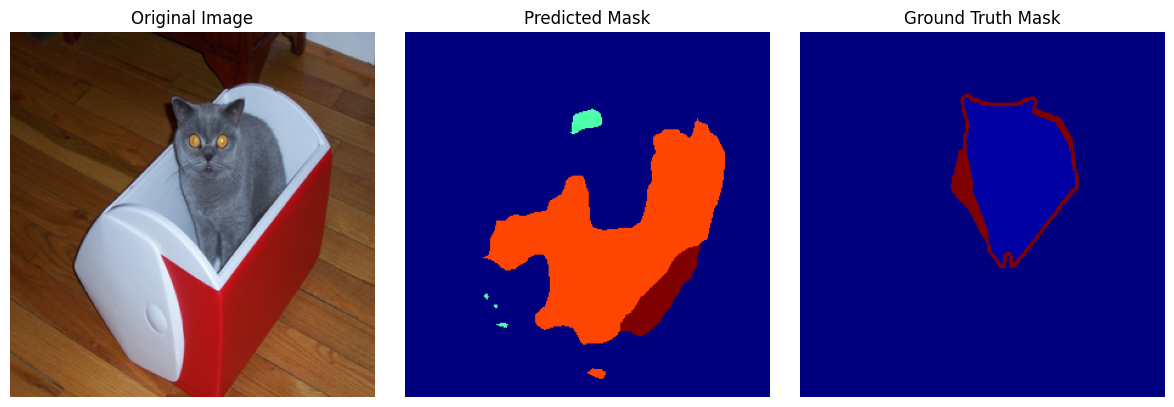

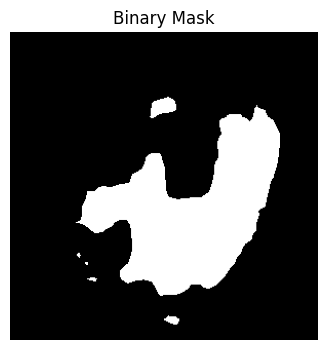

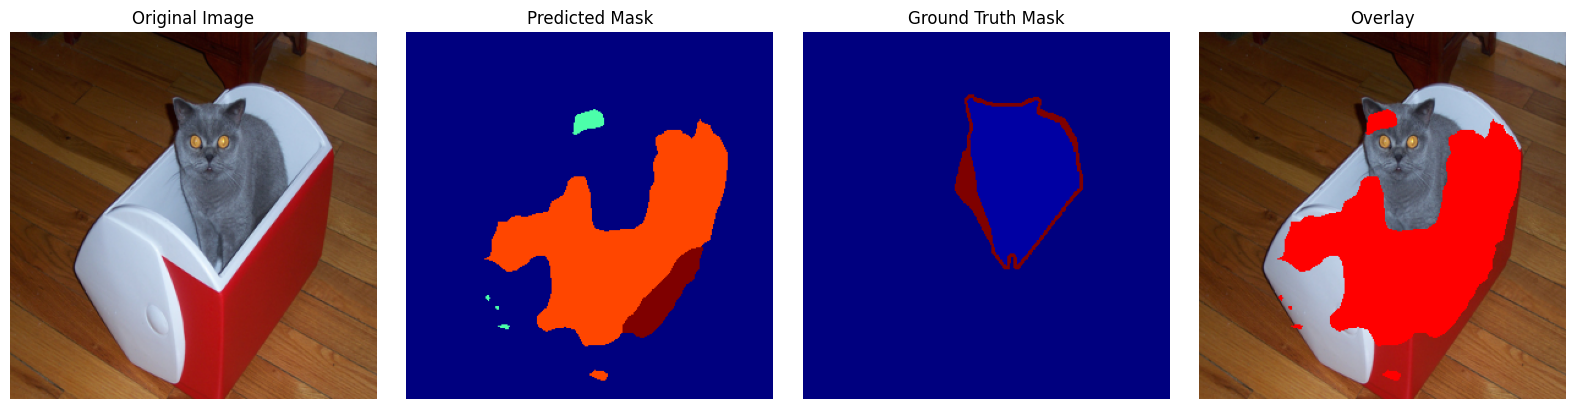

In [ ]:
# Example inference on validation samples

for idx in [0, 10]:

    pred, binary_mask, elapsed = predict_single_image(
        X_val[idx], model, device, use_tta=True
    )

    print(f"Sample {idx} — inference time: {elapsed:.4f}s")

    # Multi-class visualization
    visualize_segmentation(
        X_val[idx],
        pred,
        y_val[idx]
    )

    # Binary mask visualization
    plt.figure(figsize=(4,4))
    plt.imshow(binary_mask, cmap="gray")
    plt.title("Binary Mask")
    plt.axis("off")
    plt.show()

    # Overlay visualization
    visualize_segmentation_with_overlay(
        X_val[idx],
        pred,
        y_val[idx]
    )

#Evaluation

**Evaluation metrics**

Model performance is evaluated using the Dice coefficient averaged across all 21 classes, including background.

The final score reported in the competition is:

Dice / FLOPS

This metric encourages models that are both accurate and computationally efficient.

In [ ]:
model = VOCModel(num_classes=21).to(device)
model.load_state_dict(torch.load("MobileUNet_best.pth", map_location=device))
model.eval()

VOCModel(
  (backbone_stage1): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(64, 

In [ ]:

# Evaluation metrics

def macro_dice_score(outputs, masks, num_classes=21, ignore_index=255):
    """
    Batch-level macro Dice score.
    Ignores pixels with label 255.
    """

    preds = torch.argmax(outputs, dim=1)

    valid = masks != ignore_index
    preds = preds[valid]
    masks = masks[valid]

    dice_scores = []

    for cls in range(num_classes):

        p = (preds == cls).float()
        m = (masks == cls).float()

        union = p.sum() + m.sum()

        if union == 0:
            dice_scores.append(torch.tensor(1.0, device=outputs.device))
        else:
            # Correctly calculate intersection before computing Dice
            inter = (p * m).sum()
            dice_scores.append((2 * inter) / (union + 1e-6))

    return torch.mean(torch.stack(dice_scores))


def mean_iou_score(outputs, masks, num_classes=21, ignore_index=255, smooth=1e-6):
    """
    Batch-level mean IoU.
    Ignores pixels labeled 255.
    """

    preds = torch.argmax(outputs, dim=1)

    valid = masks != ignore_index
    preds = preds[valid]
    masks = masks[valid]

    iou_scores = []

    for cls in range(num_classes):

        p = (preds == cls)
        m = (masks == cls)

        inter = (p & m).sum().float()
        union = (p | m).sum().float()

        iou_scores.append((inter + smooth) / (union + smooth))

    return torch.mean(torch.stack(iou_scores))


def compute_dataset_binary_dice(model, loader, device, ignore_index=255):
    model.eval()
    inter, union = 0.0, 0.0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)
            preds = torch.argmax(logits, dim=1)

            # binary conversion
            preds = (preds > 0)
            masks = (masks > 0)

            valid = masks != ignore_index

            p = preds[valid].float()
            m = masks[valid].float()

            inter += (p * m).sum().item()
            union += (p.sum() + m.sum()).item()

    return (2 * inter) / (union + 1e-6)


**Full validation metrics**

In [ ]:
# -----------------------------
# Build test loader
# -----------------------------
test_dataset = VOCSegDataset(X_test, y_test, augment=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# -----------------------------
# Evaluation setup
# -----------------------------
model.eval()

class_weights = torch.ones(21, device=device)
class_weights[0] = 0.05

ce_loss = nn.CrossEntropyLoss(
    weight=class_weights,
    ignore_index=255,
    label_smoothing=0.1
)

dice_loss = DiceLoss()

test_loss = 0.0
test_acc = 0.0
test_dice = 0.0
test_iou = 0.0


# Evaluation loop

with torch.no_grad():

    for imgs, masks in test_loader:

        imgs = imgs.to(device)
        masks = masks.to(device).long()

        outputs = model(imgs)

        loss = 0.5 * ce_loss(outputs, masks) + 0.5 * dice_loss(outputs, masks)

        test_loss += loss.item()
        test_acc  += pixel_accuracy(outputs, masks).item()
        test_dice += macro_dice_score(outputs, masks).item()
        test_iou  += mean_iou_score(outputs, masks).item()


# Average metrics
n = len(test_loader)

test_loss /= n
test_acc  /= n
test_dice /= n
test_iou  /= n


print(
    f"test_loss: {test_loss:.4f}  "
    f"test_acc: {test_acc:.4f}  "
    f"test_dice: {test_dice:.4f}  "
    f"test_iou: {test_iou:.4f}"
)

NameError: name 'DiceLoss' is not defined

**Inference on Test Folder**

In [ ]:
def run_inference(input_folder, output_folder, model, device, show_samples=5):

    os.makedirs(output_folder, exist_ok=True)

    model.eval()

    image_files = [
        f for f in os.listdir(input_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    shown = 0

    with torch.no_grad():

        for fname in tqdm(image_files):

            img_path = os.path.join(input_folder, fname)

            img = np.array(
                Image.open(img_path).convert("RGB")
            ).astype(np.float32)

            original = img.copy()

            # normalize
            img = img / 255.0
            img = (img - MEAN) / STD

            tensor = (
                torch.from_numpy(img)
                .permute(2,0,1)
                .unsqueeze(0)
                .float()
                .to(device)
            )

            output = model(tensor)

            pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

            binary_mask = (pred > 0).astype(np.uint8) * 255

            out_path = os.path.join(output_folder, fname)

            Image.fromarray(binary_mask).save(out_path)


            if shown < show_samples:

                fig, axes = plt.subplots(1,3,figsize=(12,4))

                axes[0].imshow(original.astype(np.uint8))
                axes[0].set_title("Original")
                axes[0].axis("off")

                axes[1].imshow(pred, cmap="jet")
                axes[1].set_title("Class Prediction")
                axes[1].axis("off")

                axes[2].imshow(binary_mask, cmap="gray")
                axes[2].set_title("Binary Mask")
                axes[2].axis("off")

                plt.show()

                shown += 1


# Example run
input_folder = "/content/VOCdevkit/VOC2012/JPEGImages"
output_folder = "group7_output"

run_inference(input_folder, output_folder, model, device)

#Final metrics (FLOPs + Dice)

In [ ]:
img = X_test[0]

pred, _, _ = predict_single_image(img, model, device)

print(np.unique(pred))

In [ ]:
model = VOCModel(num_classes=21).to(device)
model.load_state_dict(torch.load("MobileUNet_best.pth", map_location=device), strict=False)
model.to(device)
model.eval()

In [ ]:

# Compute FLOPs and parameters

dummy = torch.randn(1, 3, 300, 300).to(device)

with torch.no_grad():

    flops, params = profile(
        model,
        inputs=(dummy,),
        verbose=False
    )

gflops = flops / 1e9

print(f"FLOPs per image (GFLOPs): {gflops:.4f}")
print(f"Parameters: {params/1e6:.2f} M")

# Build test loader


test_dataset = VOCSegDataset(
    X_test,
    y_test,
    augment=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# Compute dataset-level Dice score


with torch.no_grad():

    dice_score_final = compute_dataset_binary_dice(
        model,
        test_loader,
        device
    )


dice_per_flops = dice_score_final / gflops

print("\nLeaderboard Evaluation Metrics")
print("-------------------------------")

print(f"Dice Score (0–1)      : {dice_score_final:.4f}")
print(f"FLOPs (G)             : {gflops:.4f}")
print(f"Dice / FLOPs          : {dice_per_flops:.4f}")

In [ ]:
print(dummy.shape)
out = model(dummy)
print(out.shape)

In [ ]:
# Evaluation on augmented_test_sample

import zipfile


#Download zip from Google Drive
file_id = "1LlBeOMyhsi0L43BnYrMyQIOGrhGt1imB"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "augmented_test_sample.zip", quiet=False)

with zipfile.ZipFile("augmented_test_sample.zip", "r") as z:
    z.extractall("augmented_test_sample")

#Set paths
AUG_IMG_DIR  = "augmented_test_sample/JPEGImages"
AUG_MASK_DIR = "augmented_test_sample/SegmentationClass"

#Load image IDs
aug_ids = [os.path.splitext(f)[0] for f in os.listdir(AUG_IMG_DIR)
           if f.lower().endswith(".jpg")]

print(f"Augmented test images found: {len(aug_ids)}")

#Load data
X_aug, y_aug = load_data_voc(aug_ids, AUG_IMG_DIR, AUG_MASK_DIR)
print(f"X_aug: {X_aug.shape}  y_aug: {y_aug.shape}")

#Build DataLoader
aug_dataset = VOCSegDataset(X_aug, y_aug, augment=False)

aug_loader = DataLoader(
    aug_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

#Compute Dice score
aug_dice = compute_dataset_binary_dice(model, aug_loader, device)

print(f"\nAugmented test Dice: {aug_dice:.4f}")

#Run inference and save masks
run_inference(AUG_IMG_DIR, "group7_output", model, device)

print("Masks saved to group7_output/")

For BInary Masks

In [ ]:
import argparse
import sys

# Handling arguments safely inside a notebook environment
parser = argparse.ArgumentParser(description="VOC Segmentation Inference — Group 7")
parser.add_argument("--in_dir", type=str, default="/content/VOCdevkit/VOC2012/JPEGImages",
                    help="Path to folder containing test images")
parser.add_argument("--out_dir", type=str, default="group7_output",
                    help="Path to output folder for binary masks")

# Use parse_known_args() so it doesn't crash when run directly inside Jupyter/Colab
args, unknown = parser.parse_known_args()

# Run the existing inference method (which is defined in Cell 26)
run_inference(args.in_dir, args.out_dir, model, device)